# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [63]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [64]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

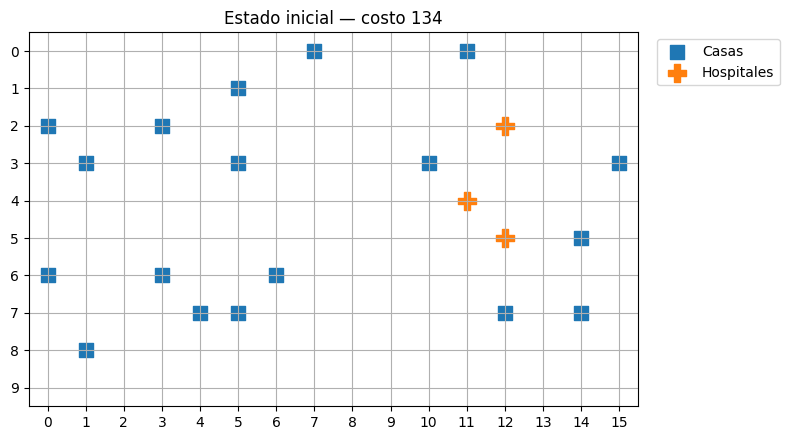

In [65]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [66]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


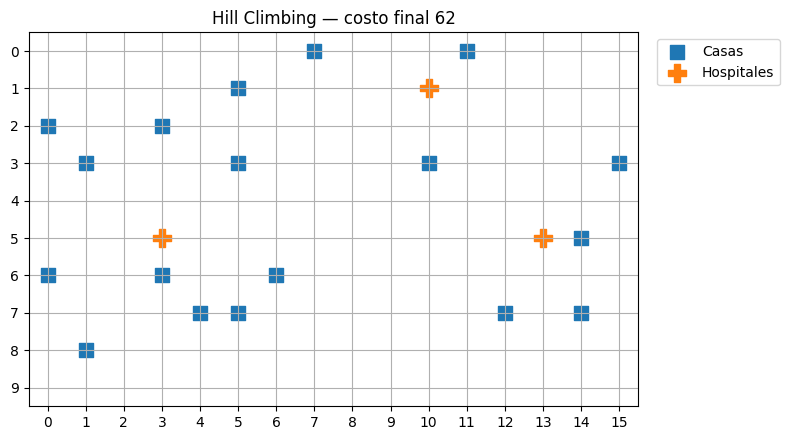

In [67]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

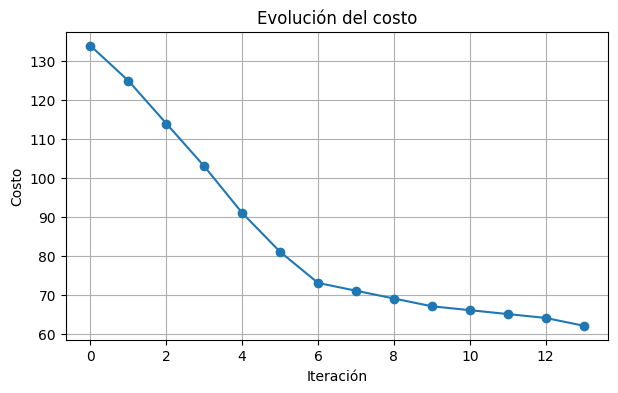

In [68]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


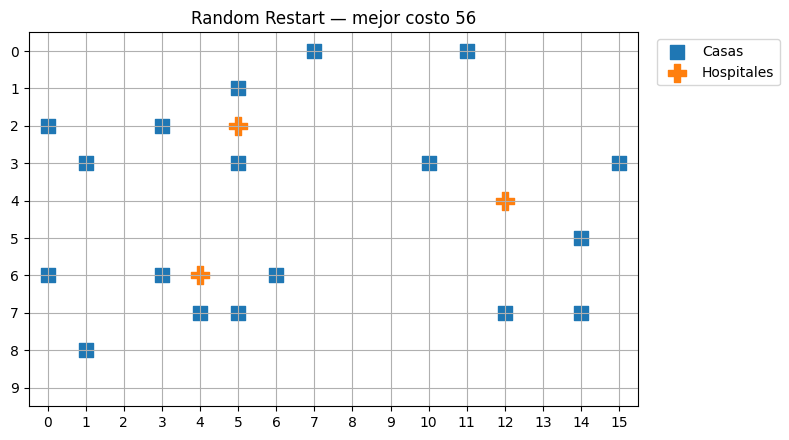

In [69]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

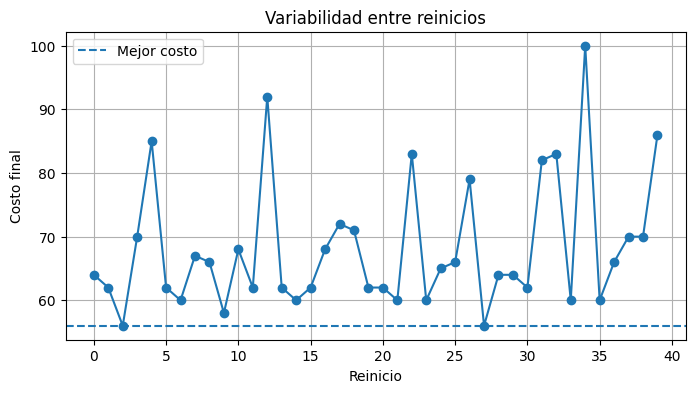

In [70]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

In [71]:
# TODO: implementa la distancia euclídea y una nueva función de costo.
def euclidean(a, b):
    return ((a[0] - b[0])**2 + (a[1] - b[1])**2) ** 0.5 


def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)
               for house in houses)

In [80]:
costo_manhattan = total_cost(houses, solution)
costo_euclideo = total_cost_euclidean(houses, solution)

print('Mismo estado, costo Manhattan:', costo_manhattan)
print('Mismo estado, costo Euclídeo:', round(costo_euclideo, 2))

Mismo estado, costo Manhattan: 62
Mismo estado, costo Euclídeo: 48.24


**Explicación**\
Al evaluar la misma solución óptima con ambas métricas, el costo Manhattan (62) resultó mayor que el costo Euclídeo (48.24). Esto es esperado: la distancia Euclídea (línea recta) siempre es menor o igual a la distancia Manhattan (movimiento en cuadrícula) entre los mismos dos puntos, por la desigualdad triangular. Por eso los valores de costo no son directamente comparables entre sí, una diferencia de 62 vs. 48.24 no significa que la solución euclídea sea "mejor", sino que ambas métricas miden la distancia de forma distinta sobre el mismo espacio.

### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [72]:
# TODO: completa el experimento.
results = []
for k in range(1, 6):
    best_k, _ = random_restart(HEIGHT, WIDTH, houses, k, restarts=40, seed=SEED)
    results.append((k, best_k['final_cost']))

results

[(1, 114), (2, 76), (3, 56), (4, 46), (5, 38)]

**¿Agregar hospitales reduce el costo?**  
Para responder esto se es conveniente graficarlo de la siguiente manera:

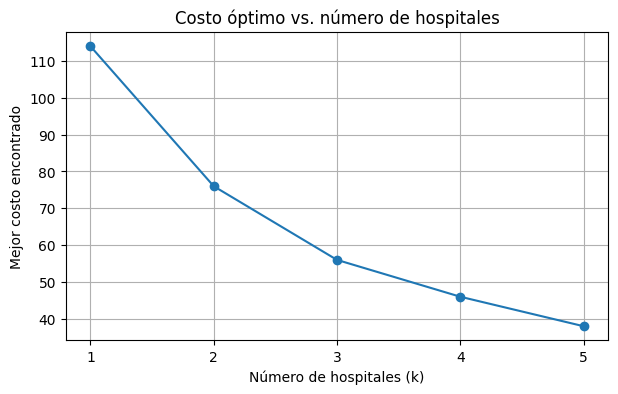

In [73]:
ks = [r[0] for r in results]
costs = [r[1] for r in results]

plt.figure(figsize=(7, 4))
plt.plot(ks, costs, marker='o')
plt.xlabel('Número de hospitales (k)')
plt.ylabel('Mejor costo encontrado')
plt.title('Costo óptimo vs. número de hospitales')
plt.xticks(ks)
plt.grid(True)
plt.show()

**Explicación**  
|k Hospitales|Costo|Reducción respecto al anterior|
|--|--|--|
|1|114|--|
|2|76|-38|
|3|56|-20|
|4|46|-10|
|5|38|-8|

Esta reducción no es constante ya que va disminuyendo, ya que se evidencia que pasar de 1 hospital a 2 mejora el costo en 38 puntos, siendo esta el mejor de los resultados y las reducciones se vuelven cada vez mas pequeñas conforme se agregan mas hospitales. Esto sugiere que, en un escenario real, habria que evaluar el costo de construir cada hospital adicional sobre el beneficio marginal decreciente que aporta, ya que en algun punto el ahorro de distancia ya no justifica el costo de un nuevo hospital.

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

**Resultado**\
Se usará Manhattan <= 2 para definir que movimientos son válidos. Esto agrega, ademas de los 4 movimientos originales:
* 4 movimientos de 2 celdas en línea recta: (-2,0), (2,0), (0,-2), (0,2)
* 4 movimientos diagonales de "1+1": (-1,-1), (-1,1), (1,-1), (1,1)

En total, 12 posibles desplazamientos por hospital (antes eran 4).

In [74]:
def neighbors_of_state_extended(height, width, houses, hospitals):
    neighbors = []
    moves = [
        (-1, 0), (1, 0), (0, -1), (0, 1),      # 1 celda (original)
        (-2, 0), (2, 0), (0, -2), (0, 2),      # 2 celdas en línea recta
        (-1, -1), (-1, 1), (1, -1), (1, 1),    # 2 celdas en diagonal
    ]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

**Probar cuantos vecinos genera**

In [75]:
neighbors_1 = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
neighbors_2 = neighbors_of_state_extended(HEIGHT, WIDTH, houses, initial_hospitals)

print('Vecinos con movimiento de 1 celda:', len(neighbors_1))
print('Vecinos con movimiento de hasta 2 celdas:', len(neighbors_2))

Vecinos con movimiento de 1 celda: 12
Vecinos con movimiento de hasta 2 celdas: 31


Como **hill_climbing** llama internamente a neighbors_of_state, se necesita una version que use la extendida. La forma mas sencilla es simplemente copiar y modificar el nombre manteniendo la logica del original

In [76]:
def hill_climbing_extended(height, width, houses, num_hospitals, initial_state=None,
                            max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state_extended(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

**Comparar Resultados**

In [77]:
sol_1celda, hist_1celda, states_1celda = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals, rng=random.Random(SEED)
)

sol_2celdas, hist_2celdas, states_2celdas = hill_climbing_extended(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals, rng=random.Random(SEED)
)

print('Vecindario 1 celda — costo final:', hist_1celda[-1], '| iteraciones:', len(hist_1celda) - 1)
print('Vecindario 2 celdas — costo final:', hist_2celdas[-1], '| iteraciones:', len(hist_2celdas) - 1)

Vecindario 1 celda — costo final: 62 | iteraciones: 13
Vecindario 2 celdas — costo final: 60 | iteraciones: 9


**Gráfica 1: Evolución del costo por iteración**

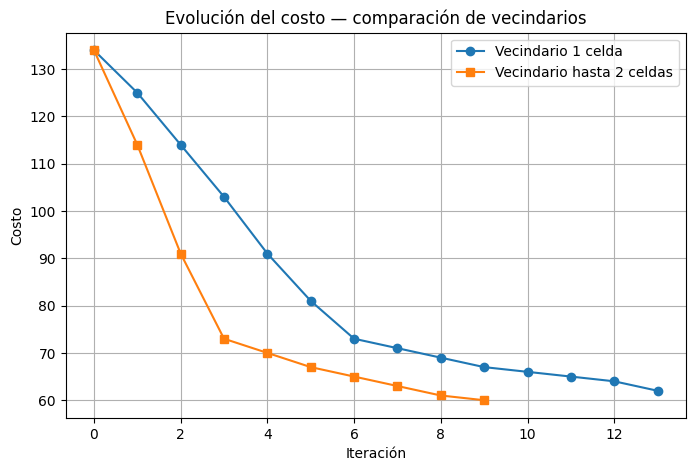

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(hist_1celda)), hist_1celda, marker='o', label='Vecindario 1 celda')
plt.plot(range(len(hist_2celdas)), hist_2celdas, marker='s', label='Vecindario hasta 2 celdas')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo — comparación de vecindarios')
plt.legend()
plt.grid(True)
plt.show()

**Gráfica 2: Comparación resumen (barras)**

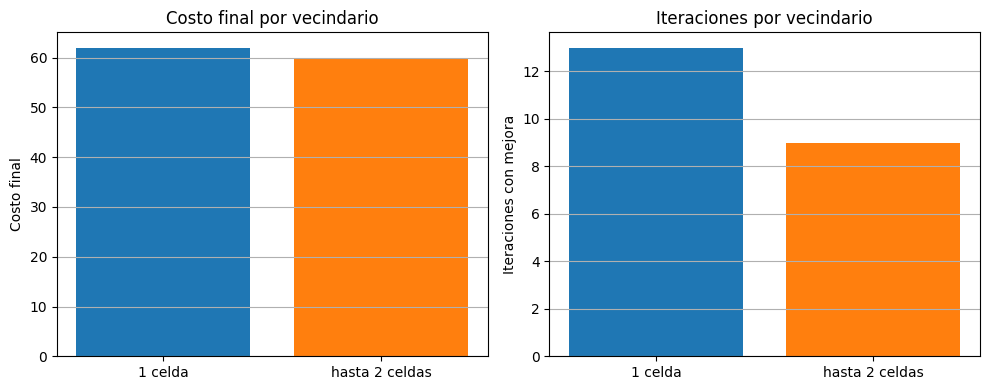

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

etiquetas = ['1 celda', 'hasta 2 celdas']

axes[0].bar(etiquetas, [hist_1celda[-1], hist_2celdas[-1]], color=['#1f77b4', '#ff7f0e'])
axes[0].set_ylabel('Costo final')
axes[0].set_title('Costo final por vecindario')
axes[0].grid(axis='y')

axes[1].bar(etiquetas, [len(hist_1celda) - 1, len(hist_2celdas) - 1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_ylabel('Iteraciones con mejora')
axes[1].set_title('Iteraciones por vecindario')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

**Explicaciones**
* ¿Mejora el Resultado? Si, levemente. El costo final bajo de 62 a 60 y ademas el algoritmo llego a este resultado en menos pasos: 9 iteraciones en vez de 13. La mejora en costo es pequeña porque Hill Climbing con 1 celda ya encontraba una solución bastante buena; el beneficio principal del vecindario extendido en este caso fue la rapidez de convergencia, no tanto la calidad final de la solución.
* ¿Cuánto aumenta el número de vecinos evaluados? Pasó de 12 a 31 vecinos por iteración — un aumento de casi el 160% (2.6 veces más). Esto ocurre porque cada hospital pasó de tener 4 movimientos posibles a 12 (aunque algunos quedan descartados por bordes del tablero o casillas ya ocupadas, por eso el número real, 31, es menor a lo teórico máximo de 3 hospitales × 12 movimientos = 36).

## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?

    Porque en cada iteración solo genera y evalúa los vecinos del estado actual, no todas las combinaciones posibles de posiciones de hospitales. En el problema, con una cuadricula de 10x16 y 3 hospitales, el espacio de busqueda completo tiene un número enorme de combinaciones posibles (de 160 elige 3). Hill Climbing evita explorar eso: parte de un estado, mira solo "a un paso de distancia", y avanza hacia donde mejora el costo. Esto lo hace mucho mas eficiente en memoria y tiempo, aunque a cambio no garantiza revisar todas las soluciones posibles.

2. ¿El resultado depende del estado inicial?

    Cada estado inicial define una "zona" del espacio de busqueda desde la cual Hill Climbing solo puede moverse localmente. Si el punto de partida cae cerca de un optimo local malo, el algoritmo se queda atrapado ahí y nunca lo sabe, porque solo ve sus vecinos inmediatos. Esto se confirma en la grafica de "Variabilidad entre Reinicios": distintos estados inciales llevaron a distintos costos finales, algunos peores que el mejor encontrado.

3. ¿Random Restart garantiza encontrar el óptimo global?

    No lo garantiza, puede que mejore las probabilidades de encontrar la mejor solucion al probar varios puntos de partida distintos y quedarse con el mejor resultado conocido, pero sigue siendo una heuristica: si ninguno de los reinicios cae en la "zona de atracción" del óptimo global, el algoritmo nunca lo encontrara. Aumentar el número de reinicios reduce la probabilidad de quedarse atascado en un óptimo local, pero no la elimina por completo, y no hay forma de saber con certeza si el mejor resultado encontrado es realmente el óptimo global o solo el mejor óptimo local visitado hasta ese momento.

4. ¿Qué información se pierde al conservar únicamente el mejor vecino?

    Se pierde toda la información sobre otros vecinos casi igual de buenos que no fueron elegidos. Por ejemplo, si dos vecinos tienen costos muy parecidos (uno con costo 60 y otro con 61), Hill Climbing descarta por completo el segundo, aunque pudiera haber llevado a una región del espacio de búsqueda con mejores óptimos a futuro. También se pierde el "historial de alternativas": una vez que te mueves a un estado, no hay forma de retroceder o comparar con caminos no tomados, a diferencia de otros algoritmos (como búsqueda en anchura o beam search) que mantienen varias rutas candidatas en paralelo. Esta es justamente una de las limitaciones que Random Restart intenta compensar, no evitando la pérdida de información en una sola corrida, sino repitiendo el experimento desde puntos distintos.